## IMPORTING LIBRARIES

In [1]:
import os
import cv2
import tensorflow as tf
import zipfile
import matplotlib.pyplot as plt
import json
import numpy as np

In [2]:
pip install roboflow

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
Note: you may need to restart the kernel to use updated packages.


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="lgNIF7tuNmwGQ53yHPqO")
project = rf.workspace("andreap").project("accurate-eyes-detection-dataset")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Accurate-Eyes-Detection-Dataset--1 in yolov11:: 100%|██████████| 120499/120499 [00:15<00:00, 7865.37it/s]


In [4]:
import shutil
# shutil.rmtree("/kaggle/working/single_person_data")
# shutil.rmtree("/kaggle/working/filtered_dataset")

In [5]:
os.mkdir("single_person_data")

In [6]:
base_dir="single_person_data"
subdirs = [
    "train/images", "train/labels", 
    "test/images", "test/labels", 
    "valid/images", "valid/labels"
]

# Create the directories
for subdir in subdirs:
    os.makedirs(os.path.join(base_dir, subdir), exist_ok=True)


In [7]:
for dirname , _ , files in os.walk("/kaggle/working/Accurate-Eyes-Detection-Dataset--1"):
    print(f"dirname {dirname} folders: {len(_)}  files :{len(files)}  ")

dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1 folders: 2  files :3  
dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1/valid folders: 2  files :0  
dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1/valid/labels folders: 0  files :2012  
dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1/valid/images folders: 0  files :2012  
dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1/train folders: 2  files :0  
dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1/train/labels folders: 0  files :58233  
dirname /kaggle/working/Accurate-Eyes-Detection-Dataset--1/train/images folders: 0  files :58233  


In [8]:
## train_dir = "/kaggle/working/Accurate-Eyes-Detection-Dataset--1/train"
valid_dir = "/kaggle/working/Accurate-Eyes-Detection-Dataset--1/valid"

train_images ="/kaggle/working/Accurate-Eyes-Detection-Dataset--1/train/images"
valid_images ="/kaggle/working/Accurate-Eyes-Detection-Dataset--1/valid/images"

train_labels ="/kaggle/working/Accurate-Eyes-Detection-Dataset--1/train/labels"
valid_labels ="/kaggle/working/Accurate-Eyes-Detection-Dataset--1/valid/labels"


In [9]:
print("TRAIN IMAGES:",len(os.listdir(train_images)))
print("TRAIN LABELS:",len(os.listdir(train_labels)))
print("VALID IMAGES:",len(os.listdir(valid_images)))
print("VALID LABELS:",len(os.listdir(valid_labels)))

TRAIN IMAGES: 58233
TRAIN LABELS: 58233
VALID IMAGES: 2012
VALID LABELS: 2012


## Visaulising The annotaions

image height  640
image width 640
image height  640
image width 640
image height  640
image width 640
image height  640
image width 640
image height  640
image width 640


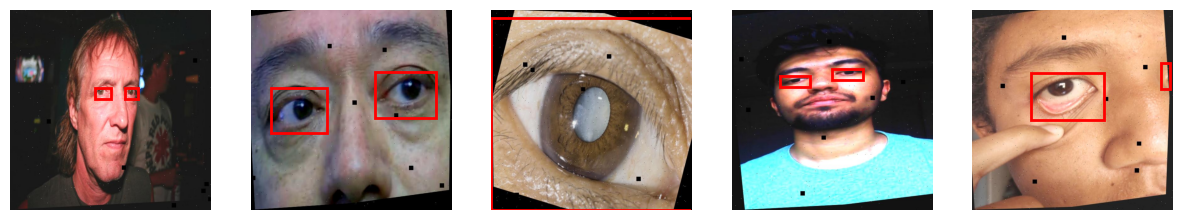

In [10]:
import os
import random
import matplotlib.patches as patches
def view_5_random_images(train_images):
    fix ,axes = plt.subplots(1,5,figsize=(15,5))
    for ax in axes:
        img = random.choice( os.listdir(train_images))
        img_path =os.path.join(train_images , img);
        img_read = plt.imread(img_path)
        img_height, img_width = img_read.shape[:2]
        print("image height ",img_height)
        print("image width" ,img_width)
        base_name, _ = os.path.splitext(img)
        label_file =f"{base_name}.txt"
        label_path=os.path.join(train_labels , label_file)
        with open(label_path, "r") as label:
            label_lines = label.readlines()
            for line in label_lines:
                parts = line.strip().split()
                x_centre ,y_centre ,box_width ,box_height =map(float,parts[1:])
                # print(x_centre,y_centre,box_width,box_height)

                x_centre *= img_width
                y_centre *= img_height
                box_width *= img_width
                box_height *= img_height

                x_min = x_centre - box_width/2
                y_min = y_centre - box_height/2
                rect = patches.Rectangle((x_min, y_min), box_width, box_height, linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
       
        ax.imshow(img_read)
        ax.axis("off") 
        # ax.imshoe( )
    plt.show()

view_5_random_images(train_images)

HERE IMAGES ARE IN SHAPE (640,640,3)

In [11]:
for dirname ,_ , images in os.walk("/kaggle/working/single_person_data"):
    print(f"dirname:{dirname} , folders:{len(_)} images:{len(images)} ")

dirname:/kaggle/working/single_person_data , folders:3 images:0 
dirname:/kaggle/working/single_person_data/test , folders:2 images:0 
dirname:/kaggle/working/single_person_data/test/labels , folders:0 images:0 
dirname:/kaggle/working/single_person_data/test/images , folders:0 images:0 
dirname:/kaggle/working/single_person_data/valid , folders:2 images:0 
dirname:/kaggle/working/single_person_data/valid/labels , folders:0 images:0 
dirname:/kaggle/working/single_person_data/valid/images , folders:0 images:0 
dirname:/kaggle/working/single_person_data/train , folders:2 images:0 
dirname:/kaggle/working/single_person_data/train/labels , folders:0 images:0 
dirname:/kaggle/working/single_person_data/train/images , folders:0 images:0 


In [12]:
new_train_dir = "/kaggle/working/single_person_data/train"
new_valid_dir = "/kaggle/working/single_person_data/valid"


new_train_images ="/kaggle/working/single_person_data/train/images"
new_valid_images ="/kaggle/working/single_person_data/valid/images"


new_train_labels ="/kaggle/working/single_person_data/train/labels"
new_valid_labels ="/kaggle/working/single_person_data/valid/labels"

## Preprocessing Images

In [13]:
import shutil

def filtering_single_person_eye(source_images,source_labels ,destination_images ,destination_labels):
    image_count = 0
    max_images=7000
    for image in os.listdir(source_images):
        if image_count >= max_images:
            print("Reached the limit of processed images.")
            break
        # image path
        image_path =os.path.join(source_images , image)
        # corresponding labels
        base_name = os.path.splitext(os.path.basename(image))[0]
        label_file_name =f"{base_name}.txt"
        label_path=os.path.join(source_labels , label_file_name)
        if os.path.exists(label_path)==False:
            print("No label correspondong to this image")
        else:
            with open(label_path,"r") as file:
                lines = [line.strip().split() for line in file.readlines()]  # Remove newline characters
                num_of_eyes =len(lines) 
                if num_of_eyes==2:
                    eye_data = [
                        {
                            "x_centre": lines[0][1],
                            "y_centre": lines[0][2],
                            "width": lines[0][3],
                            "height": lines[0][4],
                        },
                        {
                            "x_centre": lines[1][1],
                            "y_centre": lines[1][2],
                            "width": lines[1][3],
                            "height": lines[1][4],
                        },
                    ]
                    dest_label_path = os.path.join(destination_labels, f"{base_name}.json")
                    with open(dest_label_path, "w") as json_file:
                        json.dump(eye_data, json_file, indent=4)   
                        
                    dest_image_path = os.path.join(destination_images, image)
                    shutil.copy(image_path, dest_image_path)
                    image_count += 1
    print("Number of images copied is",image_count)



In [14]:
# calling the function for train ,testing and validation data
filtering_single_person_eye(train_images ,train_labels ,new_train_images ,new_train_labels)
filtering_single_person_eye(valid_images ,valid_labels ,new_valid_images ,new_valid_labels)

Reached the limit of processed images.
Number of images copied is 7000
Number of images copied is 308


In [15]:
for dirname ,_ , images in os.walk("/kaggle/working/single_person_data"):
    print(f"dirname:{dirname} , folders:{len(_)} images:{len(images)}")

dirname:/kaggle/working/single_person_data , folders:3 images:0
dirname:/kaggle/working/single_person_data/test , folders:2 images:0
dirname:/kaggle/working/single_person_data/test/labels , folders:0 images:0
dirname:/kaggle/working/single_person_data/test/images , folders:0 images:0
dirname:/kaggle/working/single_person_data/valid , folders:2 images:0
dirname:/kaggle/working/single_person_data/valid/labels , folders:0 images:308
dirname:/kaggle/working/single_person_data/valid/images , folders:0 images:308
dirname:/kaggle/working/single_person_data/train , folders:2 images:0
dirname:/kaggle/working/single_person_data/train/labels , folders:0 images:7000
dirname:/kaggle/working/single_person_data/train/images , folders:0 images:7000


WE HAVE TRAIN AND VALID DATA (NO TEST DATA)

In [16]:
train_dir = "/kaggle/working/single_person_data/train"
valid_dir = "/kaggle/working/single_person_data/valid"


train_images ="/kaggle/working/single_person_data/train/images"
valid_images ="/kaggle/working/single_person_data/valid/images"


train_labels ="/kaggle/working/single_person_data/train/labels"
valid_labels ="/kaggle/working/single_person_data/valid/labels"

In [17]:
print(random.choice(os.listdir(new_train_labels)))
one_label=os.path.join(new_train_labels , random.choice(os.listdir(new_train_labels)))
with open(one_label ,"r") as f:
    content=f.read()
    data = json.loads(content) 
    eye1,eye2=data
    print("\n",eye1)
    print(eye2)


161_jpg.rf.d9ab17c4c680b96356b216e5d04e3599.json

 {'x_centre': '0.4523602758921392', 'y_centre': '0.48231634472467916', 'width': '0.19265224672063966', 'height': '0.1302885786919079'}
{'x_centre': '0.729936399252459', 'y_centre': '0.5495696687619047', 'width': '0.18114153663473154', 'height': '0.11922380935708983'}


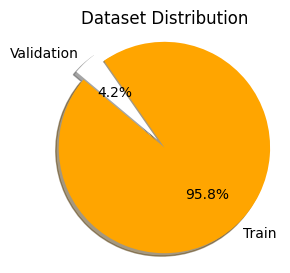

In [18]:
 
labels = ['Train', 'Validation']
sizes = [len(os.listdir(new_train_images)), len(os.listdir(new_valid_images))]
colors = ['orange', 'white']
explode = (0.1, 0)  

# Create the pie chart
plt.figure(figsize=(3, 3))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Dataset Distribution')
plt.axis('equal')  

plt.show()

## Creating Input Pipeline to load images into batches

In [19]:
import numpy as np
def load_image_and_label(image_path ,labels_dir):
    '''Loading image ,resixing image into (416,416,3) and loading corresponding bbox'''

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image= image/255.

    unique_identifier = os.path.splitext(os.path.basename(image_path))[0]
    label_file_name = f"{unique_identifier}.json"
    label_file_path = os.path.join(labels_dir ,label_file_name)

    with open(label_file_path, "r") as f:
        label_data = json.load(f)

    eye1 = label_data[0]
    eye2 = label_data[1]
    eye_detail = [ eye1["x_centre"] ,eye1["y_centre"] ,eye1["width"] ,eye1["height"] ,eye2["x_centre"] ,eye2["y_centre"] ,eye2["width"] ,eye2["height"]  ]

    return image,eye_detail



def create_dataset(images_dir ,labels_dir ,batch_size=8):
    '''Creating a tensorflow datset from image and label directory'''

    image_files=os.listdir(images_dir)
    image_paths = [ os.path.join(images_dir ,img) for img in image_files ]


    images=[]
    bboxes=[]

    for image_path in image_paths:
        image , bbox = load_image_and_label(image_path ,labels_dir)
        images.append(image)
        bboxes.append(bbox)

    images = np.array(images)
    bboxes = np.array(bboxes)
    
    images =images.astype(np.float32)
    bboxes = bboxes.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((images, bboxes))
    print(dataset)
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size)

    return dataset



In [20]:
train_dataset = create_dataset(new_train_images, new_train_labels,32)


<_TensorSliceDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(8,), dtype=tf.float32, name=None))>


In [21]:
validation_dataset = create_dataset(new_valid_images, new_valid_labels,32)

<_TensorSliceDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(8,), dtype=tf.float32, name=None))>


In [22]:
train_batch_count = train_dataset.cardinality().numpy()
validation_batch_count = validation_dataset.cardinality().numpy()
print("Batches in training",train_batch_count)
print("Batches in validation",validation_batch_count)

Batches in training 219
Batches in validation 10


In [23]:
test_dataset = train_dataset.take(19)

train_dataset = train_dataset.skip(19)

In [24]:
train_batch_count = train_dataset.cardinality().numpy()
test_batch_count = test_dataset.cardinality().numpy()
validation_batch_count = validation_dataset.cardinality().numpy()
print("Batches in training",train_batch_count)
print("Batches in test",test_batch_count)
print("Batches in validation",validation_batch_count)

Batches in training 200
Batches in test 19
Batches in validation 10


In [25]:
for images , bboxes in train_dataset.take(1):
    print("images shape",images.shape)
    print("bbox shape",bboxes.shape)

images shape (32, 224, 224, 3)
bbox shape (32, 8)


In [26]:
for images , bboxes in train_dataset.take(1):
    print(bboxes)

tf.Tensor(
[[0.37734374 0.4703125  0.134375   0.053125   0.621875   0.4703125
  0.12578125 0.05078125]
 [0.21545476 0.37378347 0.0925207  0.05989315 0.37426832 0.3918891
  0.0910492  0.06144656]
 [0.3703125  0.47421876 0.11328125 0.05859375 0.5859375  0.47265625
  0.12421875 0.05859375]
 [0.43046874 0.3078125  0.07109375 0.028125   0.571875   0.3484375
  0.071875   0.03125   ]
 [0.3567171  0.51071405 0.10483869 0.06216534 0.5329912  0.49903163
  0.1174297  0.06445588]
 [0.58115035 0.4104361  0.08463708 0.04985572 0.44056356 0.4196866
  0.08452782 0.04829323]
 [0.4114113  0.5235524  0.1300893  0.05774087 0.62392867 0.49919564
  0.12233136 0.05921246]
 [0.37276962 0.53334665 0.11454588 0.07817927 0.54348296 0.50457644
  0.11927885 0.08006955]
 [0.38667762 0.49083486 0.12386171 0.06303756 0.5734958  0.586377
  0.10621918 0.05492505]
 [0.4377323  0.34210807 0.07935253 0.04491568 0.5944226  0.32490566
  0.0870741  0.0420635 ]
 [0.33236462 0.4467225  0.15982951 0.08461903 0.6096311  0.422140

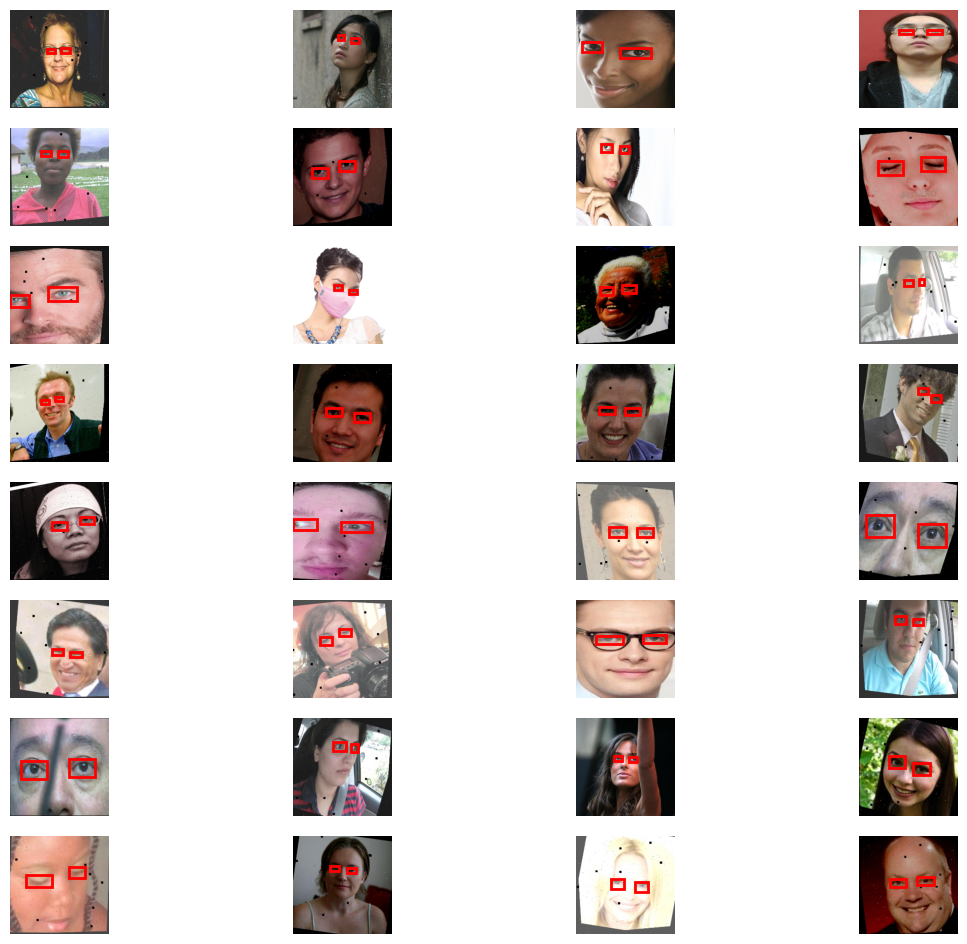

In [27]:
def plotting_a_batch():
    fig ,axes = plt.subplots(8,4,figsize=(14,12))
    image_number=0

    images_per_batch=None
    bboxes_per_batch=None
    for image , bboxes in train_dataset.take(1):
        images_per_batch=image
        bboxes_per_batch=bboxes.numpy()

    for i in range(8):
        for j in range(4):
            axes[i,j].imshow(images_per_batch[image_number])
            bounding_box = bboxes_per_batch[image_number]
            xc1 ,yc1,w1,h1,xc2,yc2,w2,h2=bounding_box*224
            x1min = xc1 -w1/2
            y1min = yc1 - h1/2

            x2min = xc2 -w2/2
            y2min = yc2 -h2/2

            rect1 = patches.Rectangle((x1min, y1min), w1, h1, linewidth=2, edgecolor='red', facecolor='none')
            axes[i,j].add_patch(rect1)

            rect2 = patches.Rectangle((x2min, y2min), w2, h2, linewidth=2, edgecolor='red', facecolor='none')
            axes[i,j].add_patch(rect2)
            
            axes[i,j].axis("off")
            image_number+=1
    plt.show()




plotting_a_batch()

## Creating Model

In [28]:
base_model = tf.keras.applications.VGG16(include_top=False)


base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Defining Custom Loss (RMSE)

In [29]:
from tensorflow.keras import backend as K

# @tf.keras.utils.register_keras_serializable()
# def rmse_loss(y_true, y_pred):
#     return K.sqrt(K.mean(K.square(y_pred - y_true), axis=-1))



def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred), axis=-1))

# Register the custom loss function using `get_custom_objects`
tf.keras.utils.get_custom_objects()['rmse_loss'] = rmse_loss

In [30]:
from tensorflow.keras.applications import VGG16
base_model = tf.keras.applications.VGG16(include_top=False)

base_model.trainable=False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")
x = base_model(inputs)

x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5),
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(8, activation="sigmoid", name="output_layer")(x)
model = tf.keras.Model(inputs, outputs)


In [31]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 7, 32)            │         147,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 7, 64)            │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 7, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 7, 7, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,277,736 (58.28 MB)

 Trainable params: 563,048 (2.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [32]:
for layer in model.layers:
    print(layer.name , layer.trainable)

input_layer True
vgg16 False
conv2d True
conv2d_1 True
conv2d_2 True
conv2d_3 True
conv2d_4 True
conv2d_5 True
conv2d_6 True
conv2d_7 True
conv2d_8 True
global_average_pooling2d True
output_layer True


In [33]:
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.saving import register_keras_serializable
@register_keras_serializable(package='Custom', name='rmse_loss')
def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred), axis=-1))
model.compile(optimizer='adam', loss=rmse_loss)

# Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 7, 7, 32)            │         147,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 7, 64)            │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 7, 7, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 7, 7, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,277,736 (58.28 MB)

 Trainable params: 563,048 (2.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [34]:
# Make the datasets repeat indefinitely
train_dataset = train_dataset.repeat()
validation_dataset = validation_dataset.repeat()

## Feature Extraction model for 10 epochs

In [35]:
# Assuming you know the number of batches in your training and validation datasets
train_batch_count = 200  
validation_batch_count = 10  

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=train_batch_count,
    validation_steps=validation_batch_count,
    epochs=10
)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 139ms/step - loss: 0.1080 - val_loss: 0.0696
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0749 - val_loss: 0.0536
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0589 - val_loss: 0.0484
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0516 - val_loss: 0.0389
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0489 - val_loss: 0.0375
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0462 - val_loss: 0.0372
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0457 - val_loss: 0.0384
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0439 - val_loss: 0.0363
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0429 - val_loss: 0.0393
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.0405 - val_loss: 0.0386


In [36]:
model.evaluate(test_dataset)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0443


0.044064246118068695

## FINE TUNING AFTER UNFREEZING LAST 5 layers of VGG

In [37]:
for layer in base_model.layers[-5:]:
    layer.trainable=True
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss=rmse_loss)


In [38]:
# Assuming you know the number of batches in your training and validation datasets
train_batch_count = 200  
validation_batch_count = 10  
initial_training_epochs = 10
history_fine_tune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=train_batch_count,
    validation_steps=validation_batch_count,
    epochs=20,
    initial_epoch=initial_training_epochs
)


Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - loss: 0.0365 - val_loss: 0.0363
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.0326 - val_loss: 0.0357
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0289 - val_loss: 0.0363
Epoch 14/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0274 - val_loss: 0.0358
Epoch 15/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0253 - val_loss: 0.0345
Epoch 16/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0241 - val_loss: 0.0343
Epoch 17/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.0223 - val_loss: 0.0335
Epoch 18/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0213 - val_loss: 0.0340
Epoch 19/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0209 - val_loss: 0.0331
Epoch 20/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0189 - val_loss: 0.0329


## Evaluating Final Model

In [39]:
model.evaluate(test_dataset)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0207


0.022815601900219917

## Testing our Model on test data (Plotting)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


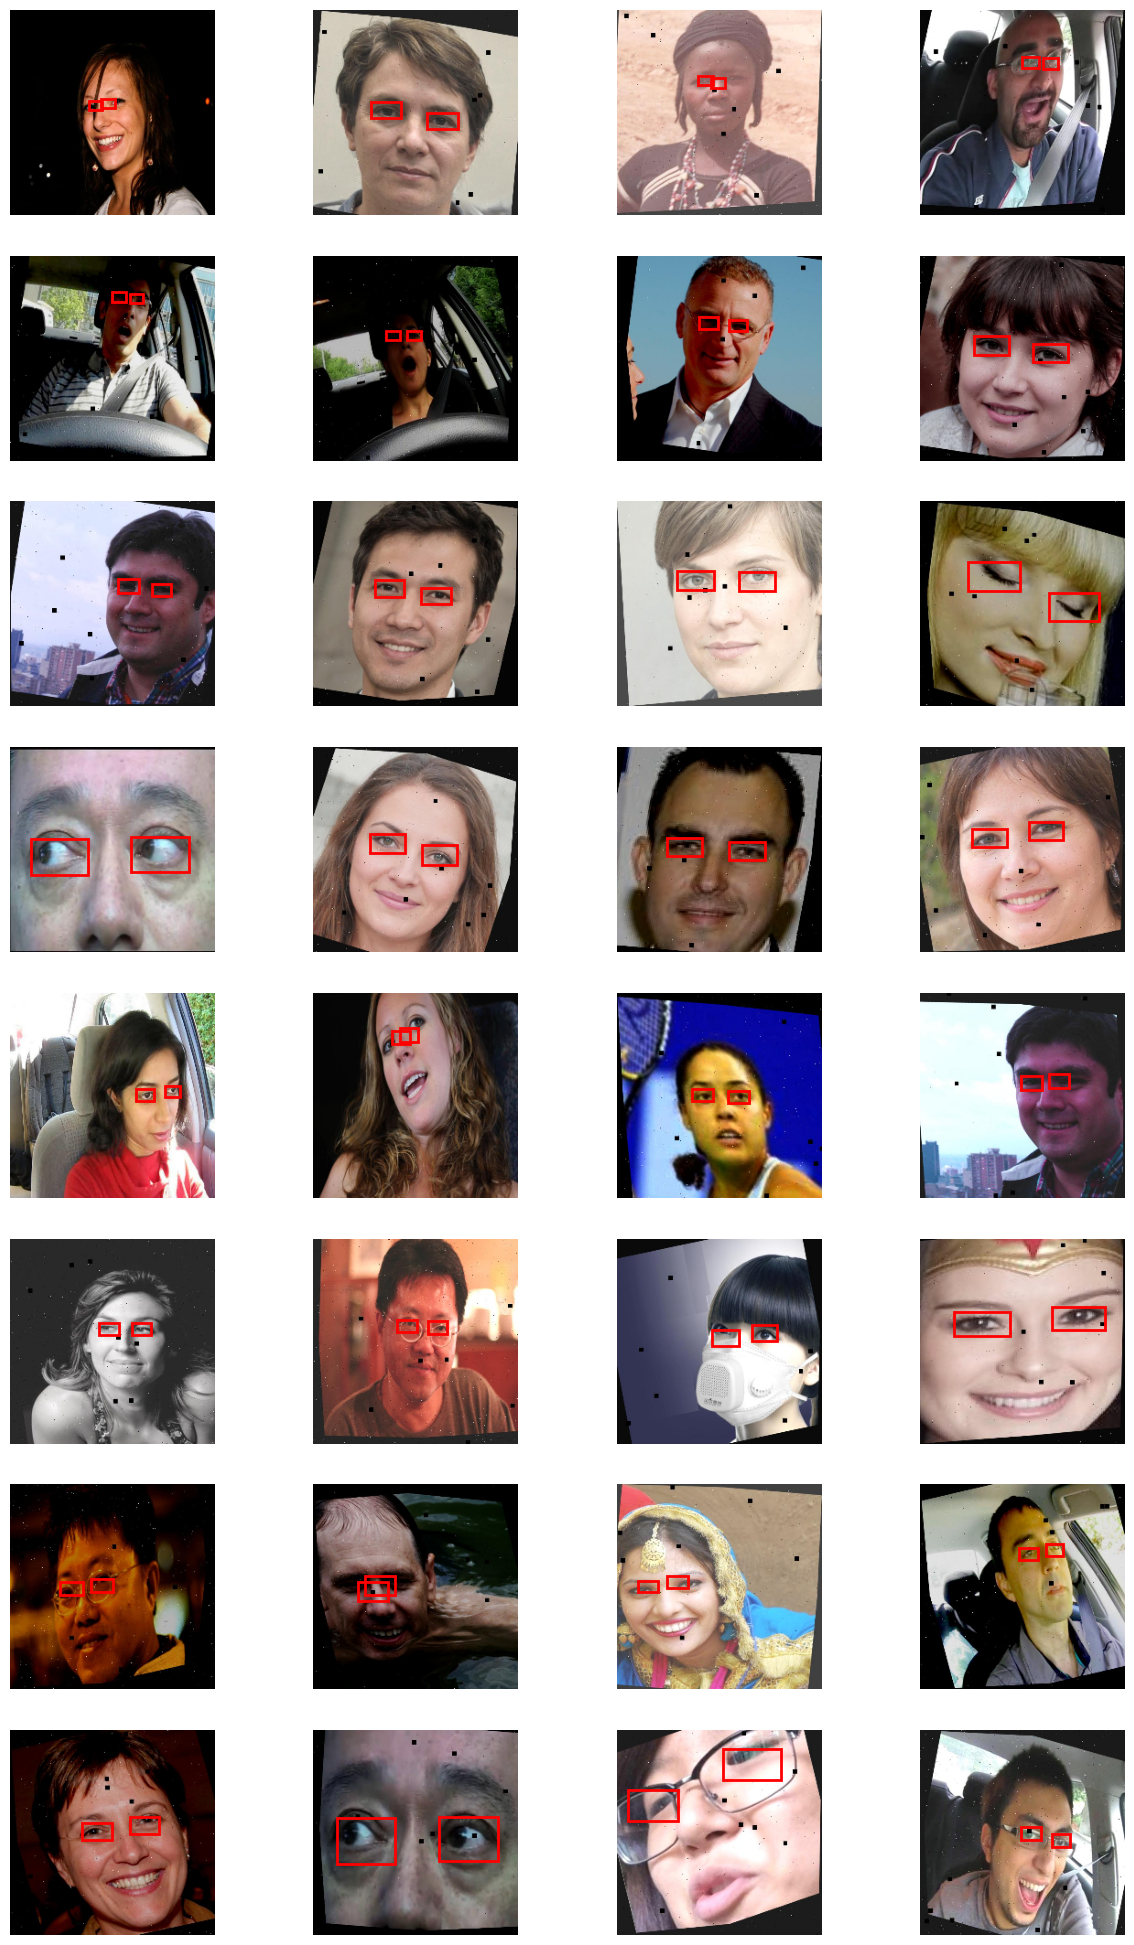

In [40]:
for images , labels in test_dataset.take(1):
    predictions =model.predict(images)
    fig,axes =plt.subplots(8,4,figsize=(15,25))
    img_num=0
    for i in range(8):
        for j in range(4):
            xc1 ,yc1,w1,h1,xc2,yc2,w2,h2=predictions[img_num]*224
            x1min = xc1 -w1/2
            y1min = yc1 - h1/2

            x2min = xc2 -w2/2
            y2min = yc2 -h2/2

            rect1 = patches.Rectangle((x1min, y1min), w1, h1, linewidth=2, edgecolor='red', facecolor='none')
            axes[i,j].add_patch(rect1)

            rect2 = patches.Rectangle((x2min, y2min), w2, h2, linewidth=2, edgecolor='red', facecolor='none')
            axes[i,j].add_patch(rect2)
            axes[i,j].imshow(images[img_num])
            axes[i,j].axis("off")
            img_num+=1
    plt.show()


In [41]:
# model.save("eye_detect_large_model2.keras")

## TRYING GIOU LOSS

In [42]:
# def plot_loss_curves(his):
#     loss=his.history["loss"]
#     val_loss =his.history["val_loss"]
#     plt.plot(loss ,label="training_loss")
#     plt.plot(val_loss ,label="validation_loss")
#     plt.legend()
#     ple.show()


# plot_loss_curves(his)

import numpy as np

import tensorflow as tf
import tensorflow as tf

def find_gio_loss_for_one_bbox(x1_centre, y1_centre, width1, height1, 
                               x2_centre, y2_centre, width2, height2):
    # Convert from center coordinates to corners for bbox1
    x1_min = x1_centre - width1 / 2
    y1_min = y1_centre - height1 / 2
    x1_max = x1_centre + width1 / 2
    y1_max = y1_centre + height1 / 2

    # Convert from center coordinates to corners for bbox2
    x2_min = x2_centre - width2 / 2
    y2_min = y2_centre - height2 / 2
    x2_max = x2_centre + width2 / 2
    y2_max = y2_centre + height2 / 2

    # Calculate intersection box using TensorFlow operations
    inter_x_min = tf.maximum(x1_min, x2_min)
    inter_y_min = tf.maximum(y1_min, y2_min)
    inter_x_max = tf.minimum(x1_max, x2_max)
    inter_y_max = tf.minimum(y1_max, y2_max)

    # Check if there is an intersection
    intersection_area = tf.maximum(0.0, inter_x_max - inter_x_min) * tf.maximum(0.0, inter_y_max - inter_y_min)

    # Calculate areas of bbox1 and bbox2
    area1 = width1 * height1
    area2 = width2 * height2

    # Union area
    union_area = area1 + area2 - intersection_area

    # IoU calculation with conditional TensorFlow operation
    iou = tf.where(union_area > 0, intersection_area / union_area, tf.zeros_like(intersection_area))

    # Calculate smallest enclosing box
    enclosing_x_min = tf.minimum(x1_min, x2_min)
    enclosing_y_min = tf.minimum(y1_min, y2_min)
    enclosing_x_max = tf.maximum(x1_max, x2_max)
    enclosing_y_max = tf.maximum(y1_max, y2_max)

    enclosing_area = (enclosing_x_max - enclosing_x_min) * (enclosing_y_max - enclosing_y_min)

    # GIoU calculation
    giou = iou - tf.where(enclosing_area > 0, (enclosing_area - union_area) / enclosing_area, tf.zeros_like(enclosing_area))

    # GIoU Loss
    giou_loss = 1 - giou

    return giou_loss
    
def GIOULOSS(y_true ,y_pred):
    eye1_loss= find_gio_loss_for_one_bbox(y_true[0],y_true[1],y_true[2],y_true[3] , y_pred[0],y_pred[1],y_pred[2],y_pred[3])
    eye2_loss= find_gio_loss_for_one_bbox(y_true[4],y_true[5],y_true[6],y_true[7] , y_pred[4],y_pred[5],y_pred[6],y_pred[7])

    return eye1_loss*eye2_loss

print("loaded")

loaded


In [43]:
from tensorflow.keras.applications import VGG16
base_model = tf.keras.applications.VGG16(include_top=False)

base_model.trainable=False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")
x = base_model(inputs)

x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5),
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
tf.keras.layers.Dropout(0.5)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(8, activation="sigmoid", name="output_layer")(x)
model2 = tf.keras.Model(inputs, outputs)




In [44]:
tf.keras.utils.get_custom_objects()['GIOULOSS'] = GIOULOSS

In [45]:

model2.compile(optimizer='adam', loss=GIOULOSS)

# Print the model summary
model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 7, 7, 32)            │         147,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 7, 7, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 7, 7, 64)            │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 7, 7, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 7, 7, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,572,904 (59.41 MB)

 Trainable params: 858,216 (3.27 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
for layer in model2.layers:
    print(layer.name ,layer.trainable)

input_layer True
vgg16 False
conv2d_9 True
conv2d_10 True
conv2d_11 True
conv2d_12 True
conv2d_13 True
conv2d_14 True
conv2d_15 True
conv2d_16 True
conv2d_17 True
conv2d_18 True
conv2d_19 True
global_average_pooling2d_1 True
output_layer True


In [47]:
# Assuming you know the number of batches in your training and validation datasets
train_batch_count = 200  
validation_batch_count = 10  

history2 = model2.fit(
    train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=train_batch_count,
    validation_steps=validation_batch_count,
    epochs=10
)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 117ms/step - loss: 0.9919 - val_loss: 1.0351
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.5881 - val_loss: 0.8560
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.5146 - val_loss: 0.6373
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.4551 - val_loss: 0.8264
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.4883 - val_loss: 0.6258
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.4501 - val_loss: 0.6631
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - loss: 0.4301 - val_loss: 0.5177
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - loss: 0.4075 - val_loss: 0.7847
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - loss: 0.3728 - val_loss: 0.5245
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - loss: 0.4153 - val_loss: 0.6497


In [48]:
model2.evaluate(test_dataset)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.4726


0.4697161316871643

In [49]:
for layer in base_model.layers[-5:]:
    layer.trainable=True
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss=GIOULOSS)

In [50]:
# Assuming you know the number of batches in your training and validation datasets
train_batch_count = 200  
validation_batch_count = 10  
initial_training_epochs = 10
history_fine_tune2 = model2.fit(
    train_dataset,
    validation_data=validation_dataset,
    steps_per_epoch=train_batch_count,
    validation_steps=validation_batch_count,
    epochs=20,
    initial_epoch=initial_training_epochs
)


Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - loss: 0.3801 - val_loss: 0.5939
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3617 - val_loss: 0.5881
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.3511 - val_loss: 0.5273
Epoch 14/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3272 - val_loss: 0.5821
Epoch 15/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3261 - val_loss: 0.5945
Epoch 16/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3289 - val_loss: 0.5467
Epoch 17/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3247 - val_loss: 0.5424
Epoch 18/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3173 - val_loss: 0.5721
Epoch 19/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3128 - val_loss: 0.5924
Epoch 20/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.3287 - val_loss: 0.5482


In [51]:
model2.evaluate(test_dataset)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.3579


0.3200545310974121